In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Bitext_support.csv")
print(df.shape)
df.head()

(26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [2]:
df.info()
print("\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB


flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


In [3]:
print(df['category'].value_counts())

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


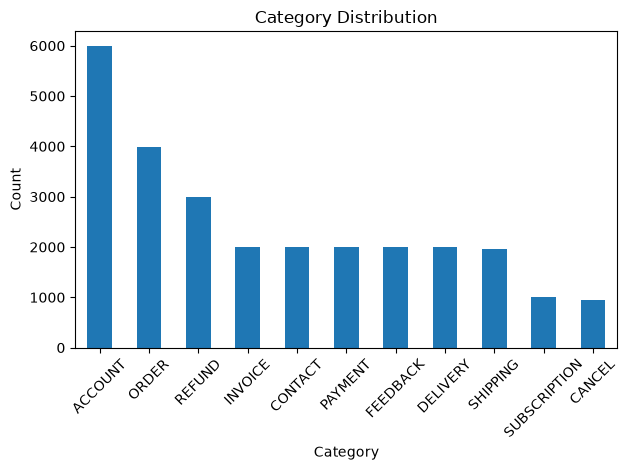

In [5]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print(df['flags'].value_counts().head(20))
print(f"\nTotal unique flags: {df['flags'].nunique()}")
print(f"\nSample flags: {df['flags'].unique()[:10]}")

flags
BL       5212
BLQ      2467
BIL      2138
BLM      1297
BILQ     1057
BLQZ      970
BLZ       902
BKL       862
BLMQ      600
BEL       533
BILM      521
BCL       484
BCIL      427
BILQZ     412
BILP      363
B         353
BK        352
BQ        340
BKLZ      322
BLW       309
Name: count, dtype: int64

Total unique flags: 394

Sample flags: <ArrowStringArray>
['B', 'BQZ', 'BLQZ', 'BL', 'BCELN', 'BI', 'BCLN', 'BLQ', 'BQ', 'BLZ']
Length: 10, dtype: str


count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: instruction_length, dtype: float64


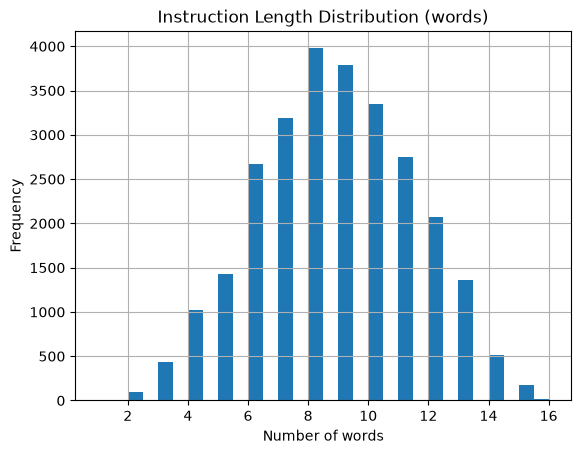

In [7]:
df['instruction_length'] = df['instruction'].apply(lambda x: len(str(x).split()))
print(df['instruction_length'].describe())

df['instruction_length'].hist(bins=30)
plt.title('Instruction Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

In [8]:
duplicate_count = df['instruction'].duplicated().sum()
print(f"Duplicate instructions: {duplicate_count}")
print(f"Unique instructions: {df['instruction'].nunique()}")

dup_descriptions = df[df.duplicated(subset=['instruction'], keep=False)]
dup_check = dup_descriptions.groupby('instruction')['category'].nunique()
print(f"Instructions appearing in multiple categories: {(dup_check > 1).sum()}")

Duplicate instructions: 2237
Unique instructions: 24635
Instructions appearing in multiple categories: 0


In [9]:
print(f"Responses populated: {df['response'].notna().sum()}")
print(f"Percentage: {df['response'].notna().sum() / len(df) * 100:.2f}%")
print()
for i in range(5):
    print(f"Category: {df['category'].iloc[i]}")
    print(f"Instruction: {df['instruction'].iloc[i]}")
    print(f"Response: {df['response'].iloc[i]}")
    print("---")

Responses populated: 26872
Percentage: 100.00%

Category: ORDER
Instruction: question about cancelling order {{Order Number}}
Response: I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.
---
Category: ORDER
Instruction: i have a question about cancelling oorder {{Order Number}}
Response: I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please go ahead and let me know what specific question you have, and I'll provide you with all the information and guidance you need. Your satisfaction is my top priority.
---
Category: ORDER
Instruction: i need help cancelling puchase {{Order Number}}
Response: I can sense that you're seeking assistance with canceling your purchase with the purchase number {{Order Number}}. I apologize for any inconvenience caused, and I'm here to guide

In [10]:
from collections import Counter

for cat in df['category'].unique():
    subset = df[df['category'] == cat]
    words = " ".join(subset['instruction'].str.lower()).split()
    print(f"\n=== {cat} ===")
    print(Counter(words).most_common(8))


=== ORDER ===
[('{{order', 2907), ('number}}', 2495), ('i', 2477), ('to', 1942), ('order', 1628), ('purchase', 1495), ('of', 1187), ('help', 1049)]

=== SHIPPING ===
[('address', 1637), ('i', 1314), ('to', 885), ('shipping', 776), ('delivery', 753), ('my', 732), ('the', 654), ('a', 511)]

=== CANCEL ===
[('the', 892), ('i', 700), ('to', 536), ('early', 363), ('see', 349), ('termination', 340), ('check', 306), ('help', 239)]

=== INVOICE ===
[('i', 1529), ('to', 1403), ('from', 916), ('{{person', 887), ('bill', 766), ('do', 759), ('name}}', 732), ('my', 728)]

=== PAYMENT ===
[('payment', 1526), ('i', 1271), ('to', 1113), ('with', 775), ('help', 622), ('of', 551), ('the', 418), ('online', 346)]

=== REFUND ===
[('i', 2601), ('to', 1555), ('of', 1056), ('a', 1054), ('can', 968), ('help', 760), ('for', 670), ('my', 659)]

=== FEEDBACK ===
[('a', 1655), ('to', 1297), ('i', 1217), ('your', 677), ('help', 543), ('against', 543), ('feedback', 530), ('for', 475)]

=== CONTACT ===
[('to', 1776

In [11]:
print(f"Total unique intents: {df['intent'].nunique()}")
print(df['intent'].value_counts())

Total unique intents: 27
intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
set_up_shipping_address      997
delete_account               995
delivery_options             995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64


In [12]:
# Confirm intent names are clean strings, no weird characters
print(df['intent'].unique())
print(f"\nSample: category='{df['category'].iloc[0]}', intent='{df['intent'].iloc[0]}'")

# Verify each intent maps to exactly one category (should be true)
intent_category_map = df.groupby('intent')['category'].nunique()
print(f"\nIntents mapping to more than one category: {(intent_category_map > 1).sum()}")

<ArrowStringArray>
[            'cancel_order',             'change_order',
  'change_shipping_address',   'check_cancellation_fee',
            'check_invoice',    'check_payment_methods',
      'check_refund_policy',                'complaint',
 'contact_customer_service',      'contact_human_agent',
           'create_account',           'delete_account',
         'delivery_options',          'delivery_period',
             'edit_account',              'get_invoice',
               'get_refund',  'newsletter_subscription',
            'payment_issue',              'place_order',
         'recover_password',    'registration_problems',
                   'review',  'set_up_shipping_address',
           'switch_account',              'track_order',
             'track_refund']
Length: 27, dtype: str

Sample: category='ORDER', intent='cancel_order'

Intents mapping to more than one category: 0


## EDA Findings — Bitext Customer Support Dataset

1. Shape: (26872, 5)
2. Columns: flags, instruction, category, intent, response
3. Missing values: none
4. Categories: 11 (ORDER, ACCOUNT, REFUND, SHIPPING, INVOICE, 
   CONTACT, PAYMENT, FEEDBACK, DELIVERY, SUBSCRIPTION, CANCEL)
5. Class balance: mild imbalance (ACCOUNT=5986, CANCEL=950)
   → will handle with class_weight='balanced' in models
6. Instruction length: short utterances (5-20 words typically)
   → good for DistilBERT (handles short text well)
7. Placeholders: {{order number}}, {{person name}} etc. present
   → will strip during preprocessing
8. Duplicates across categories: [fill in from Cell 7]
9. Response column: 100% populated, real responses
   → will use as reference for agent evaluation
10. Signal confirmed: distinct vocabulary per category

## Decisions for Preprocessing
- Input: instruction column
- Label: category column (11 classes)
- Placeholder handling: strip {{...}} patterns
- Class imbalance: use class_weight='balanced'
- No stopword removal needed for DistilBERT 
  (BERT uses subword tokenization, needs raw text)